# XGBoost Classifier for Credit Risk Feature Evaluation

This notebook demonstrates how to use XGBoost for:

+ Multivariate feature selection
+ Model tuning using GridSearchCV
+ Evaluation using AUC
+ Ranking features by predictive power

This pipeline is aligned with scorecard development practices and supports downstream comparison with logistic regression and random forest.


In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt

## Load Multivariate-Ready Dataset

This dataset was prepared from earlier WOE encoding steps and excludes IV columns. It’s now ready for multivariate analysis with tree-based models like XGBoost.

In [2]:
data0 = pd.read_csv(r'/content/drive/MyDrive/Colab Notebooks/Scorecard_Project/Internal_test_0_datasetForMultivariateVSExceptIV.csv', index_col=[0])

In [3]:
data = data0.copy()
target = data['loan_status']
features = data.drop(columns=['loan_status'])

## Define Recursive Feature Importance Reduction Function


This function trains an XGBoost model, calculates feature importances, and evaluates AUC after dropping less predictive variables. It's used to identify compact, high-performance feature sets.

In [4]:
def feature_reduce_xgb(threshold, features, bad):
    '''
    1) Train on an XGBoost classifier and compute the AUC on the same data;
    2) Drop features to keep top features that have threshold (eg: 0.99) feature importance
    3) Repeat 1) 2) until there's only one feature left
    4) Plot the AUC
    '''
    AUC_train = []
    AUC_test = []
    num_features = []

    # Split the data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(features, bad, test_size=0.2, random_state=20)

    while X_train.shape[1] > 1:
        # Define an XGBoost classifier
        fs_clf = XGBClassifier(n_estimators=100, max_depth=2, learning_rate=0.1, random_state=20)

        # Train the classifier
        fs_clf.fit(X_train, y_train)

        # Get the feature importance values
        importances = fs_clf.feature_importances_
        feature_names = X_train.columns # list of feature names

        # Sort the feature importances in descending order
        sorted_index = np.argsort(importances)[::-1]

        # Print the sorted feature importance values
        for i in sorted_index:
            print(f"Feature {feature_names[i]}: {importances[i]}")

        # Predict probabilities
        y_train_pred = fs_clf.predict_proba(X_train)[:, 1]
        y_test_pred = fs_clf.predict_proba(X_test)[:, 1]

        # Compute the AUC
        auc_train = roc_auc_score(y_train, y_train_pred)
        auc_test = roc_auc_score(y_test, y_test_pred)

        # Print number of features
        print('Number of Features: {}'.format(X_train.shape[1]))
        # Print the AUC
        print(f"AUC Train: {auc_train:.4f}")
        print(f"AUC Test: {auc_test:.4f}")

        # Record number of features, AUC
        num_features.append(X_train.shape[1])
        AUC_train.append(auc_train)
        AUC_test.append(auc_test)

        # Add up the feature importances until they reach the threshold
        num = 0
        cum_importance = 0.0
        for feature_index in sorted_index:
            cum_importance += importances[feature_index]
            num += 1
            if cum_importance >= threshold:
                break

        # If number of features no longer decrease, decrement 1
        if num_features[-1] == num:
            num -= 1

        # Select the top num features
        top_features = feature_names[sorted_index[:num]]
        X_train = X_train[top_features]
        X_test = X_test[top_features]

    # Plot the AUC
    fig = plt.figure(figsize=(15,8))
    x = np.arange(len(num_features))
    plt.plot(x, AUC_train, label='Train AUC')
    plt.plot(x, AUC_test, label='Test AUC')
    plt.xticks(x, num_features, rotation=90, ha='right', fontsize=6)
    plt.xlabel('Number of Features')
    plt.ylabel('AUC')
    plt.title('AUC vs. Number of Features Curve')
    plt.legend()
    plt.tight_layout()
    plt.show()


Feature previous_loan_defaults_on_file: 0.4893050491809845
Feature loan_percent_income: 0.1624356210231781
Feature loan_int_rate: 0.1190996989607811
Feature person_home_ownership: 0.0922134667634964
Feature person_income: 0.060535117983818054
Feature loan_intent: 0.034941963851451874
Feature credit_score: 0.031027061864733696
Feature loan_amnt: 0.010442042723298073
Feature cb_person_cred_hist_length: 0.0
Feature person_emp_exp: 0.0
Feature person_education: 0.0
Number of Features: 11
AUC Train: 0.9698
AUC Test: 0.9698
Feature previous_loan_defaults_on_file: 0.5906785130500793
Feature loan_percent_income: 0.16267718374729156
Feature loan_int_rate: 0.14908632636070251
Feature person_home_ownership: 0.09755804389715195
Number of Features: 4
AUC Train: 0.9534
AUC Test: 0.9490
Feature previous_loan_defaults_on_file: 0.6639201641082764
Feature loan_percent_income: 0.18284575641155243
Feature loan_int_rate: 0.1532340794801712
Number of Features: 3
AUC Train: 0.9455
AUC Test: 0.9404
Feature pr

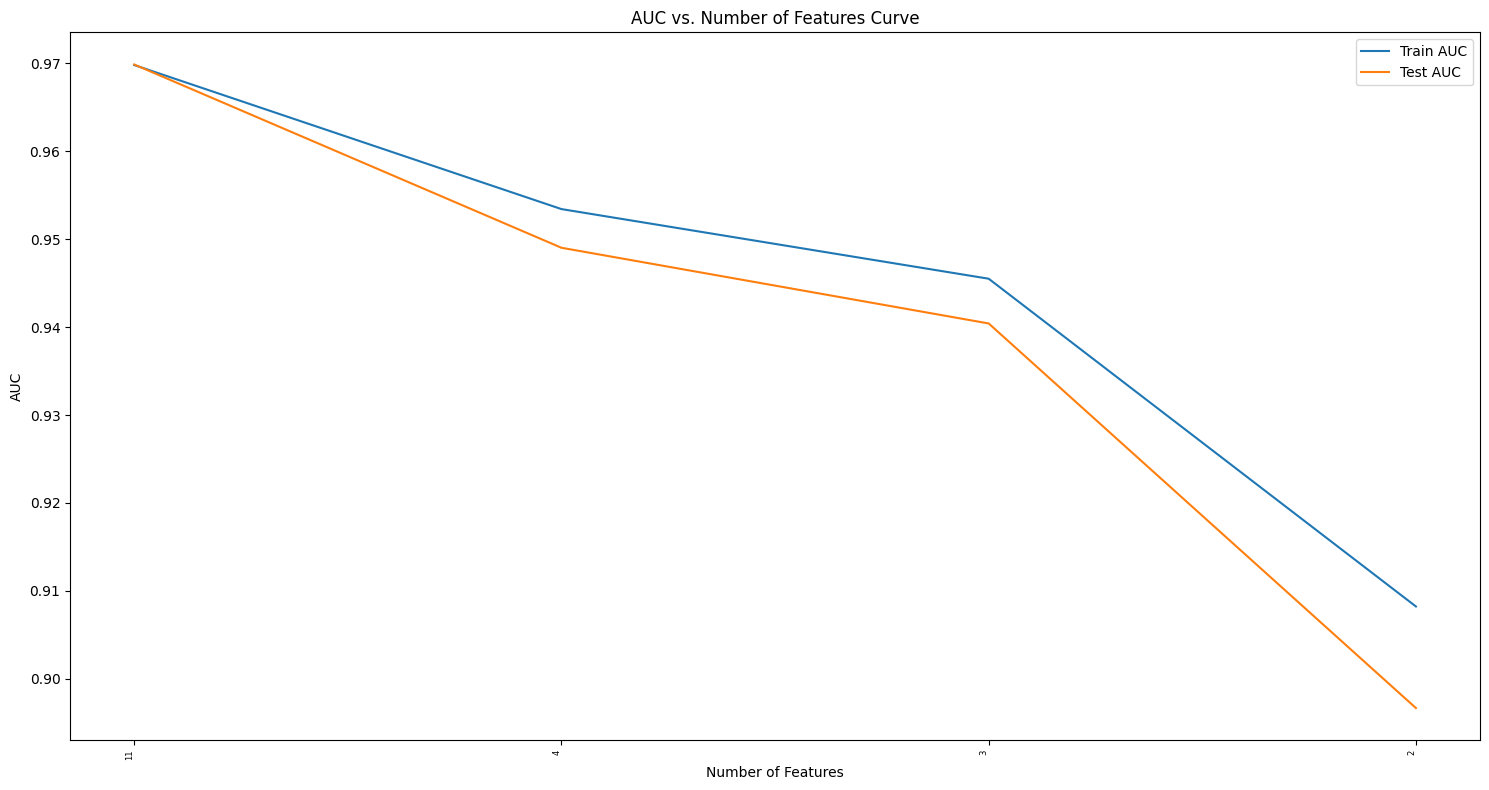

In [5]:
feature_reduce_xgb(threshold=0.80, features=features, bad=target)

## Hyperparameter Tuning Using GridSearchCV

We use cross-validation to tune max_depth, n_estimators, subsample, and learning_rate. The goal is to improve generalization performance of the XGBoost model.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=20)

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.5, 0.7]
}

# Initialize the XGBClassifier
xgb_clf = XGBClassifier(random_state=42)

grid_search = GridSearchCV(estimator=xgb_clf, param_grid=param_grid, cv=5, scoring='roc_auc',return_train_score=True)
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")
print("Hyperparameters\t\t\t\t\t\t\t\t\t\t\t\t\t\tTrain AUC\t\tTest AUC")
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    avg_train_auc = grid_search.cv_results_['mean_train_score'][i]
    avg_test_auc = grid_search.cv_results_['mean_test_score'][i]
    print(f"{params}\t{avg_train_auc:.4f}\t\t{avg_test_auc:.4f}")

print("The best parameters are {}".format(grid_search.best_params_))
print("The mean ROC AUC of the best parameters is {}".format(grid_search.best_score_))


Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.7}
Hyperparameters														Train AUC		Test AUC
{'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.5}	0.9473		0.9468
{'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.7}	0.9462		0.9458
{'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.5}	0.9534		0.9530
{'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.7}	0.9533		0.9528
{'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.5}	0.9585		0.9581
{'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.7}	0.9585		0.9580
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.5}	0.9576		0.9571
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}	0.9576		0.9572
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.5}	0.9618		0.9611
{'learning

In [7]:
best_params

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.7}

In [8]:
best_params_updated = {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.7}

## Train Final Model and Evaluate AUC



We retrain the model on the full training data using the optimal parameters. AUC is computed on both train and test splits to assess model performance.

In [9]:
# Train the model with the best parameters
best_xgb_clf = XGBClassifier(**best_params_updated, random_state=20)
best_xgb_clf.fit(X_train, y_train)

y_train_pred = best_xgb_clf.predict_proba(X_train)[:, 1]
y_test_pred = best_xgb_clf.predict_proba(X_test)[:, 1]

# Compute the AUC
auc_train = roc_auc_score(y_train, y_train_pred)
auc_test = roc_auc_score(y_test, y_test_pred)

print(f"AUC Train: {auc_train:.4f}")
print(f"AUC Test: {auc_test:.4f}")

# Get feature importances
importances = best_xgb_clf.feature_importances_
feature_names = features.columns

feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'XGB_Importance': importances
})

# Sort the DataFrame by importance and add rank
feature_importances = feature_importances.sort_values(by='XGB_Importance', ascending=False).reset_index(drop=True)
feature_importances['XGB_Rank'] = feature_importances['XGB_Importance'].rank(ascending=False).astype(int)

AUC Train: 0.9938
AUC Test: 0.9772


                           Feature  XGB_Importance  XGB_Rank
0   previous_loan_defaults_on_file        0.856242         1
1              loan_percent_income        0.038059         2
2            person_home_ownership        0.033033         3
3                    loan_int_rate        0.019474         4
4                      loan_intent        0.013337         5
5                    person_income        0.013230         6
6                     credit_score        0.007106         7
7                        loan_amnt        0.005294         8
8                   person_emp_exp        0.005072         9
9       cb_person_cred_hist_length        0.005005        10
10                person_education        0.004149        11


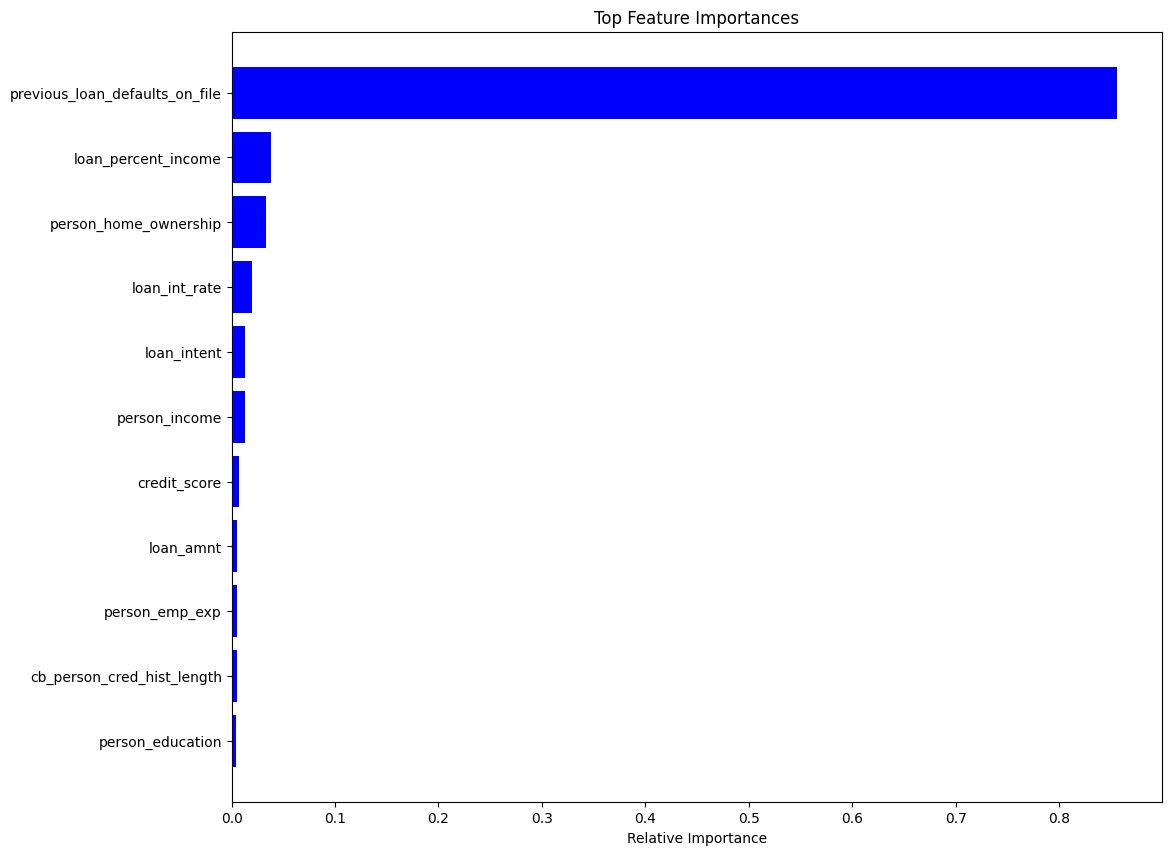

In [10]:
top_features = feature_importances.head(20)
print(top_features)

plt.figure(figsize=(12, 10))
plt.title("Top Feature Importances")
plt.barh(top_features['Feature'], top_features['XGB_Importance'], color='b', align='center')
plt.gca().invert_yaxis()
plt.xlabel("Relative Importance")
plt.show()

In [11]:
feature_importances

,Feature,XGB_Importance,XGB_Rank
0,previous_loan_defaults_on_file,0.856242,1
1,loan_percent_income,0.038059,2
2,person_home_ownership,0.033033,3
3,loan_int_rate,0.019474,4
4,loan_intent,0.013337,5
5,person_income,0.013230,6
6,credit_score,0.007106,7
7,loan_amnt,0.005294,8
8,person_emp_exp,0.005072,9
9,cb_person_cred_hist_length,0.005005,10


## Interpretation of Feature Importance

The XGBoost model reveals strong predictive signals from a small set of features:

- **previous_loan_defaults_on_file** overwhelmingly dominates with ~86% of total importance. This indicates prior default behavior is the single strongest driver of risk in this dataset — a finding that aligns well with domain expectations.

- **loan_percent_income**, **person_home_ownership**, and **loan_int_rate** follow as moderately important, all reflecting affordability and financial leverage.

- Traditional demographic features like **person_income**, **education**, and **employment experience** contribute marginally, suggesting weaker direct impact in this dataset (or potentially nonlinear interactions better captured by trees).

This ranking can now inform:
- Downstream **feature selection** for logistic regression or scorecard modeling
- **Monitoring frameworks**, prioritizing variables with the greatest risk impact
- Model simplification and explainability strategies


In [12]:
feature_importances.to_csv(r'/content/drive/MyDrive/Colab Notebooks/Scorecard_Project/Internal_XGBoost.csv')